<a href="https://colab.research.google.com/github/divya374r1/Neural-Network-and-Deep-Learning/blob/main/Copy_of_exp_6%2C7%2C8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/2
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 635s 543ms/step - accuracy: 0.6656 - loss: 0.6188 - val_accuracy: 0.7154 - val_loss: 0.5528
Epoch 2/2
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 603s 517ms/step - accuracy: 0.7821 - loss: 0.4597 - val_accuracy: 0.7666 - val_loss: 0.5043
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


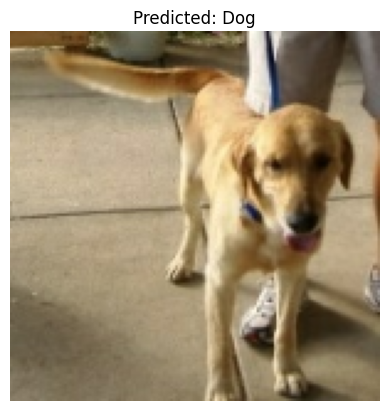

In [ ]:
# =========================================
# IMAGE CLASSIFICATION (CATS vs DOGS)
# =========================================

!pip install -q tensorflow-datasets

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# LOAD DATASET
(ds_train, ds_test), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]'],
    as_supervised=True,
    with_info=True
)

# PREPROCESS FUNCTION
def preprocess(image, label):
    image = tf.image.resize(image, (150, 150))
    image = image / 255.0
    return image, label

# APPLY PREPROCESSING
train_ds = ds_train.map(preprocess).batch(16)
val_ds = ds_test.map(preprocess).batch(16)

class_names = ['Cat', 'Dog']

# BUILD MODEL
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax')
])

# COMPILE MODEL
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN MODEL
model.fit(train_ds, validation_data=val_ds, epochs=2)

# TAKE ONE IMAGE FROM DATASET
for images, labels in val_ds.take(1):
    img = images[0]
    true_label = labels[0]
    break

# PREDICT
img_input = tf.expand_dims(img, 0)
prediction = model.predict(img_input)
predicted_class = class_names[np.argmax(prediction)]

# DISPLAY IMAGE
plt.imshow(img)
plt.title("Predicted: " + predicted_class)
plt.axis("off")
plt.show()

In [ ]:
# =========================================
# EXPERIMENT 6: SENTIMENT ANALYSIS USING RNN
# =========================================

# STEP 1: IMPORT LIBRARIES
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# STEP 2: LOAD DATASET (IMDB)
vocab_size = 10000
max_length = 200

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

# STEP 3: PAD SEQUENCES
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_length)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_length)

# STEP 4: BUILD RNN MODEL
model = models.Sequential([
    layers.Embedding(vocab_size, 64, input_length=max_length),
    layers.SimpleRNN(64),
    layers.Dense(1, activation='sigmoid')
])

# STEP 5: COMPILE
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# STEP 6: TRAIN
model.fit(x_train, y_train, epochs=2, batch_size=64, validation_split=0.2)

# STEP 7: EVALUATE
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

# STEP 8: PREDICT SAMPLE REVIEW
sample_review = x_test[0]
prediction = model.predict(sample_review.reshape(1, -1))

if prediction > 0.5:
    print("Predicted Sentiment: Positive")
else:
    print("Predicted Sentiment: Negative")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.6350 - loss: 0.6223 - val_accuracy: 0.7874 - val_loss: 0.4505
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.8369 - loss: 0.3748 - val_accuracy: 0.8348 - val_loss: 0.4087
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8305 - loss: 0.4080
Test Accuracy: 0.83051997423172
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
Predicted Sentiment: Positive


Epoch 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10513/10513 ━━━━━━━━━━━━━━━━━━━━ 216s 20ms/step - loss: 0.0028 - val_loss: 6.0138e-04
Epoch 2/2
10513/10513 ━━━━━━━━━━━━━━━━━━━━ 216s 21ms/step - loss: 6.1986e-04 - val_loss: 6.2685e-04
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


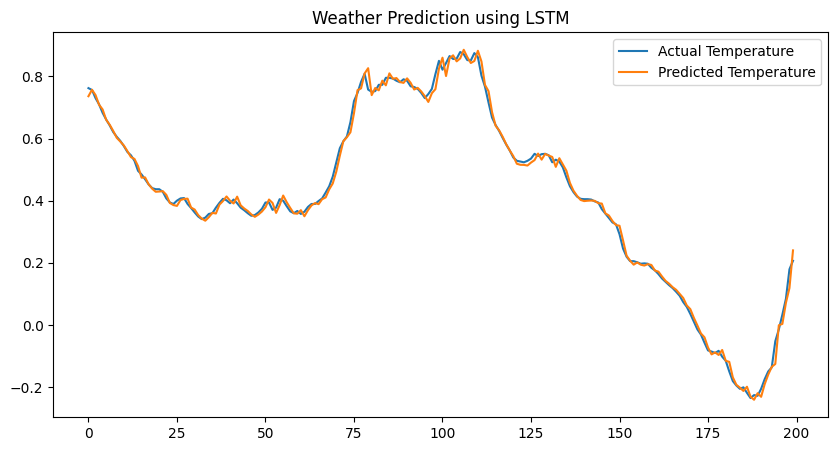

In [ ]:
# =========================================
# EXPERIMENT 7: WEATHER PREDICTION USING LSTM (FINAL FIXED)
# =========================================

# STEP 1: IMPORT LIBRARIES
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# STEP 2: DOWNLOAD DATASET
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
path = tf.keras.utils.get_file("jena_climate.zip", origin=url, extract=True)

# STEP 3: FIND CSV FILE AUTOMATICALLY
base_dir = os.path.dirname(path)

csv_file = None
for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)

# LOAD DATA
df = pd.read_csv(csv_file)

# STEP 4: USE TEMPERATURE COLUMN
data = df["T (degC)"].values

# STEP 5: NORMALIZE
data = (data - np.mean(data)) / np.std(data)

# STEP 6: CREATE SEQUENCES
sequence_length = 50
X, y = [], []

for i in range(len(data) - sequence_length):
    X.append(data[i:i+sequence_length])
    y.append(data[i+sequence_length])

X = np.array(X)
y = np.array(y)

# RESHAPE FOR LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))

# STEP 7: SPLIT DATA
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# STEP 8: BUILD MODEL
model = models.Sequential([
    layers.LSTM(50, activation='tanh', input_shape=(sequence_length,1)),
    layers.Dense(1)
])

# STEP 9: COMPILE
model.compile(optimizer='adam', loss='mse')

# STEP 10: TRAIN (FAST)
model.fit(
    X_train, y_train,
    epochs=2,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# STEP 11: PREDICT
predictions = model.predict(X_test[:200])

# STEP 12: PLOT RESULT
plt.figure(figsize=(10,5))
plt.plot(y_test[:200], label='Actual Temperature')
plt.plot(predictions, label='Predicted Temperature')
plt.legend()
plt.title("Weather Prediction using LSTM")
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 10.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Saving car image.avif to car image.avif

image 1/1 /content/car image.avif: 448x640 1 person, 1 car, 299.2ms
Speed: 4.5ms preprocess, 299.2ms inference, 35.8ms postprocess per image at shape (1, 3, 448, 640)


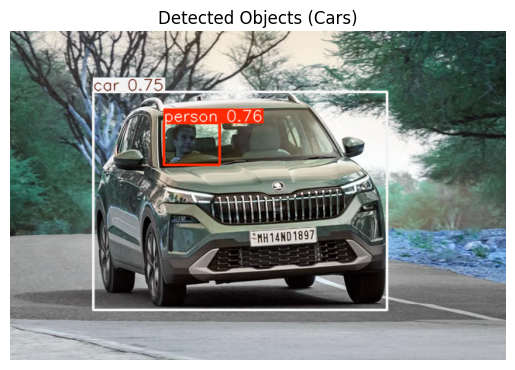

In [ ]:

# EXPERIMENT 8: OBJECT DETECTION USING YOLO
# (CAR + NUMBER PLATE DETECTION)

# STEP 1: INSTALL YOLO
!pip install -q ultralytics

# STEP 2: IMPORT LIBRARIES
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# STEP 3: LOAD YOLO MODEL (PRETRAINED)
model = YOLO("yolov8n.pt")   # small fast model

# STEP 4: UPLOAD IMAGE
from google.colab import files
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# STEP 5: RUN DETECTION
results = model(image_path)

# STEP 6: SHOW RESULT
for r in results:
    img = r.plot()   # draws bounding boxes
    plt.imshow(img)
    plt.axis("off")
    plt.title("Detected Objects (Cars)")
    plt.show()